# 01 — Kagome Antiferromagnet: Lattice & Hamiltonian

> **spinq-vqe** | ARPA Quantum Logical Systems (QONDRA)

## Context

Mn₃Sn is a room-temperature antiferromagnet with a **Kagome spin lattice** — a 2D network of
corner-sharing equilateral triangles with three magnetic sublattices (A, B, C).  
A 2026 UTokyo experiment demonstrated spin–orbit torque (SOT) switching of its antiferromagnetic
order, making it a leading candidate for next-generation spintronic memory.

This notebook builds the quantum-mechanical description of this system:

1. **Lattice geometry** — Kagome graph with sublattice labelling  
2. **Heisenberg Hamiltonian** — exchange, anisotropy, and Zeeman terms  
3. **Hamiltonian inspection** — Pauli string decomposition  
4. **Exact diagonalization (ED)** — ground-state energy and spectral gap for N = 9, 18 sites  
5. **Scaling analysis** — how spectrum changes with system size

The ED energies here serve as **reference targets** for the VQE benchmarks in Notebook 02.

### References
- Sachdev (1992) PRB 45, 12377 — Kagome Heisenberg spin liquid  
- Yan, Huse & White (2011) Science 332, 1173 — DMRG spin liquid evidence  
- Consiglio et al. (2022) PRR 4, 033257 — VQE on Kagome  
- Nakatsuji et al. (2022) Ann. Phys. 447 — Mn₃Sn review

In [1]:
from __future__ import annotations

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scipy.linalg
import scipy.sparse
import scipy.sparse.linalg
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pennylane as qp

from spinq_vqe import kagome, utils

# Ensure output directories exist
os.makedirs('../figures', exist_ok=True)
os.makedirs('../data', exist_ok=True)

# Pastel palette
PAL = {
    'A': '#B8B8E8',
    'B': '#F5C9A0',
    'C': '#A8D8B0',
    'edge': '#D0D0D0',
    'blue': '#9BB8D4',
    'coral': '#E8A598',
    'lavender': '#B8B8E8',
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#EBEBEB',
    'grid.linewidth': 0.7,
    'figure.dpi': 110,
})

print('Imports OK — PennyLane', qp.__version__)

Imports OK — PennyLane 0.45.0


---
## 1. Kagome Lattice Geometry

In [2]:
G9  = kagome.kagome_graph(n_cells=3)
G18 = kagome.kagome_graph(n_cells=6)

print(f'9-site  graph : {kagome.n_sites(G9)} sites,  {kagome.n_bonds(G9)} bonds')
print(f'18-site graph : {kagome.n_sites(G18)} sites, {kagome.n_bonds(G18)} bonds')

partition = kagome.sublattice_partition(G9)
for sl, label in zip([0, 1, 2], ['A', 'B', 'C']):
    print(f'  Sublattice {label}: sites {partition[sl]}')

9-site  graph : 9 sites,  11 bonds
18-site graph : 18 sites, 23 bonds
  Sublattice A: sites [0, 3, 6]
  Sublattice B: sites [1, 4, 7]
  Sublattice C: sites [2, 5, 8]


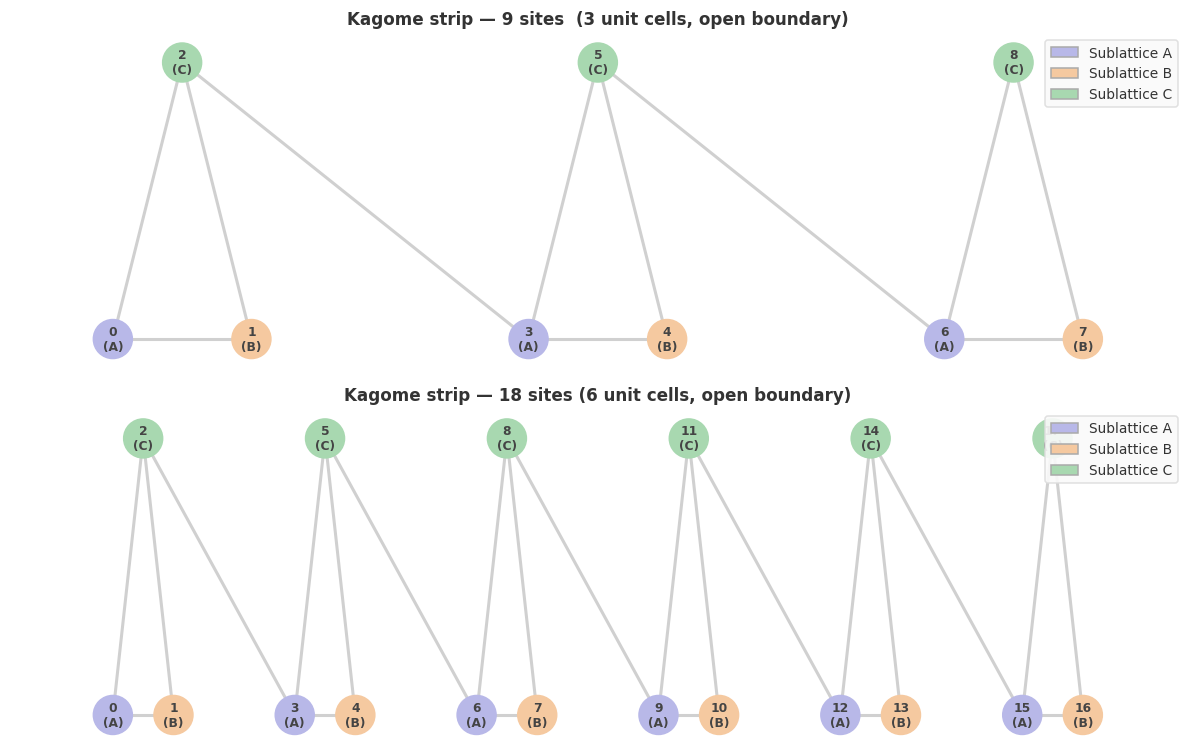

Saved → figures/kagome_lattice.png


In [3]:
def kagome_layout(G):
    n_cells = G.number_of_nodes() // 3
    pos = {}
    for k in range(n_cells):
        pos[3*k]   = (3*k,       0.0)
        pos[3*k+1] = (3*k + 1.0, 0.0)
        pos[3*k+2] = (3*k + 0.5, 0.866)
    return pos


def draw_kagome(G, title='', ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3))
    pos = kagome_layout(G)
    sl_color = {0: PAL['A'], 1: PAL['B'], 2: PAL['C']}
    node_colors = [sl_color[G.nodes[n]['sublattice']] for n in G.nodes]
    node_labels = {
        n: f"{n}\n({'ABC'[G.nodes[n]['sublattice']]})"
        for n in G.nodes
    }
    nx.draw_networkx(
        G, pos=pos, ax=ax,
        node_color=node_colors, node_size=650,
        labels=node_labels, font_size=8,
        font_color='#444444', font_weight='semibold',
        edge_color=PAL['edge'], width=2.0,
    )
    handles = [
        mpatches.Patch(facecolor=PAL[lbl], edgecolor='#AAAAAA', label=f'Sublattice {lbl}')
        for lbl in ['A', 'B', 'C']
    ]
    ax.legend(handles=handles, loc='upper right',
              framealpha=0.9, edgecolor='#DDDDDD', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='semibold', color='#333333')
    ax.set_facecolor('#FAFAFA')
    ax.axis('off')


fig, axes = plt.subplots(2, 1, figsize=(11, 7))
draw_kagome(G9,  'Kagome strip — 9 sites  (3 unit cells, open boundary)', ax=axes[0])
draw_kagome(G18, 'Kagome strip — 18 sites (6 unit cells, open boundary)', ax=axes[1])
plt.tight_layout()
plt.savefig('../figures/kagome_lattice.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/kagome_lattice.png')

---
## 2. Heisenberg Hamiltonian

$$
H = J \sum_{\langle i,j \rangle} \mathbf{S}_i \cdot \mathbf{S}_j
  + D \sum_i (S_i^z)^2
  + B \sum_i S_i^z
$$

For spin-$\tfrac{1}{2}$: $\mathbf{S}_i \cdot \mathbf{S}_j = \tfrac{1}{4}(XX + YY + ZZ)_{ij}$

**Mn₃Sn parameters** (inelastic neutron scattering, Nakatsuji 2022):  
- $J \approx 4.0$ meV (antiferromagnetic)  
- $D \approx 0.3$ meV (easy-plane anisotropy)  
- $B = 0$ (no external field)

In [4]:
H9  = kagome.heisenberg_kagome_hamiltonian(G9)
H18 = kagome.heisenberg_kagome_hamiltonian(G18)

print(f'9-site  Hamiltonian : {len(H9.coeffs)} Pauli terms')
print(f'18-site Hamiltonian : {len(H18.coeffs)} Pauli terms')
print(f'J = {kagome.J_MN3SN_MEV} meV,  D = {kagome.D_MN3SN_MEV} meV')
print()
print('First 12 Pauli terms (9-site):')
print(f'{"Coeff":>12}  Operator')
print('─' * 45)
for coeff, op in zip(H9.coeffs[:12], H9.ops[:12]):
    print(f'{coeff:>12.6f}  {op}')

9-site  Hamiltonian : 42 Pauli terms
18-site Hamiltonian : 87 Pauli terms
J = 4.0 meV,  D = 0.3 meV

First 12 Pauli terms (9-site):
       Coeff  Operator
─────────────────────────────────────────────
    0.111111  X(0) @ X(1)
    0.111111  Y(0) @ Y(1)
    0.111111  Z(0) @ Z(1)
    0.111111  X(0) @ X(2)
    0.111111  Y(0) @ Y(2)
    0.111111  Z(0) @ Z(2)
    0.111111  X(1) @ X(2)
    0.111111  Y(1) @ Y(2)
    0.111111  Z(1) @ Z(2)
    0.111111  X(2) @ X(3)
    0.111111  Y(2) @ Y(3)
    0.111111  Z(2) @ Z(3)


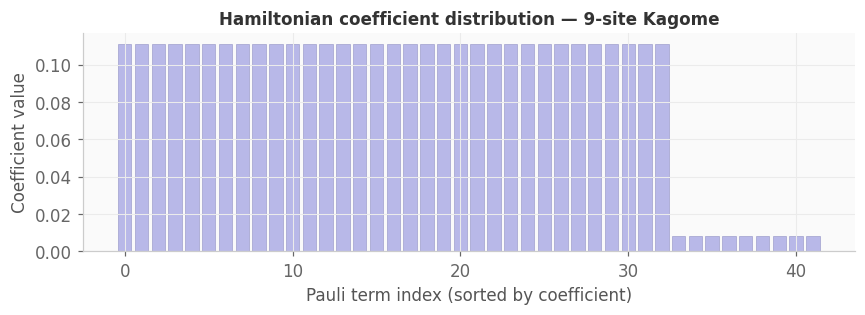

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(
    range(len(H9.coeffs)),
    sorted(H9.coeffs, reverse=True),
    color=PAL['lavender'], edgecolor='#9898C8', linewidth=0.4,
)
ax.set_xlabel('Pauli term index (sorted by coefficient)', color='#555555')
ax.set_ylabel('Coefficient value', color='#555555')
ax.set_title(
    'Hamiltonian coefficient distribution — 9-site Kagome',
    fontsize=11, fontweight='semibold', color='#333333',
)
plt.tight_layout()
plt.savefig('../figures/hamiltonian_coeffs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Exact Diagonalization

Hilbert space dimensions:
- N = 9  → dim = $2^9$ = 512 (dense ED, instant)
- N = 18 → dim = $2^{18}$ = 262 144 (sparse ED, ~30–60 s)

For N = 9 we use `qp.matrix()` → dense NumPy matrix → `np.linalg.eigvalsh`.  
For N = 18 we build the sparse Hamiltonian from Kronecker products and use `scipy.sparse.linalg.eigsh` (ARPACK).

In [6]:
import scipy.sparse as sp
from scipy.sparse import kron, eye as speye

# Single-qubit Pauli matrices (sparse)
_I2 = speye(2, format='csr', dtype=complex)
_X  = sp.csr_matrix([[0, 1], [1, 0]], dtype=complex)
_Y  = sp.csr_matrix([[0, -1j], [1j, 0]], dtype=complex)
_Z  = sp.csr_matrix([[1, 0], [0, -1]], dtype=complex)
_PAULI = {'I': _I2, 'X': _X, 'Y': _Y, 'Z': _Z}


def _two_site_op(P1_char, site_i, P2_char, site_j, n_sites):
    """
    Efficiently build P1_i ⊗ P2_j in n_sites-qubit Hilbert space.
    Assumes site_i < site_j.
    """
    assert site_i < site_j
    P1, P2 = _PAULI[P1_char], _PAULI[P2_char]

    n_left   = 2 ** site_i
    n_mid    = 2 ** (site_j - site_i - 1)
    n_right  = 2 ** (n_sites - site_j - 1)

    left  = speye(n_left,  format='csr', dtype=complex)
    mid   = speye(n_mid,   format='csr', dtype=complex)
    right = speye(n_right, format='csr', dtype=complex)

    return kron(kron(kron(kron(left, P1), mid), P2), right, format='csr')


def _single_site_op(P_char, site, n_sites):
    """Embed single-qubit Pauli P on `site` in n_sites-qubit space."""
    P = _PAULI[P_char]
    n_left  = 2 ** site
    n_right = 2 ** (n_sites - site - 1)
    return kron(kron(speye(n_left, format='csr', dtype=complex), P),
                speye(n_right, format='csr', dtype=complex), format='csr')


def build_sparse_heisenberg(G, J=4.0, D=0.3, B=0.0, normalize=True):
    """
    Build the Kagome Heisenberg Hamiltonian as a scipy CSR sparse matrix.
    Bypasses PennyLane's dense matrix for scalability to large N.
    """
    n = G.number_of_nodes()
    dim = 2 ** n
    norm = n if normalize else 1.0
    H = sp.csr_matrix((dim, dim), dtype=complex)

    J_eff = J / (4.0 * norm)
    for i, j in G.edges():
        si, sj = min(i, j), max(i, j)
        for pauli in ['X', 'Y', 'Z']:
            H = H + J_eff * _two_site_op(pauli, si, pauli, sj, n)

    if abs(D) > 1e-10:
        D_eff = D / (4.0 * norm)
        for i in range(n):
            H = H + D_eff * speye(dim, format='csr', dtype=complex)

    if abs(B) > 1e-10:
        B_eff = B / (2.0 * norm)
        for i in range(n):
            H = H + B_eff * _single_site_op('Z', i, n)

    return H


print('Helper functions defined.')

Helper functions defined.


In [7]:
# --- ED: N = 9 (dense, instant) ---
print('Exact diagonalization — 9 sites (dense)')

H9_matrix = qp.matrix(H9, wire_order=list(range(9)))
evals9_all = np.linalg.eigvalsh(H9_matrix)
evals9 = evals9_all[:6]

E0_9  = evals9[0]
gap9  = evals9[1] - evals9[0]

print(f'  Ground state energy E₀ = {E0_9:.8f}')
print(f'  Spectral gap Δ         = {gap9:.8f}')
print(f'  Lowest 6 eigenvalues   : {np.round(evals9, 6)}')

Exact diagonalization — 9 sites (dense)


  Ground state energy E₀ = -1.42190399
  Spectral gap Δ         = 0.00000000
  Lowest 6 eigenvalues   : [-1.421904 -1.421904 -1.312795 -1.312795 -1.312795 -1.312795]


In [8]:
# --- ED: N = 18 (sparse, ~30-60 s) ---
print('Exact diagonalization — 18 sites (sparse ARPACK) ...')

H18_sparse = build_sparse_heisenberg(G18,
    J=kagome.J_MN3SN_MEV, D=kagome.D_MN3SN_MEV,
    B=kagome.B_DEFAULT, normalize=True)

print(f'  Sparse matrix: {H18_sparse.shape},  nnz = {H18_sparse.nnz:,}')

evals18, _ = scipy.sparse.linalg.eigsh(H18_sparse, k=6, which='SA')
evals18 = np.sort(evals18.real)

E0_18 = evals18[0]
gap18 = evals18[1] - evals18[0]

print(f'  Ground state energy E₀ = {E0_18:.8f}')
print(f'  Spectral gap Δ         = {gap18:.8f}')
print(f'  Lowest 6 eigenvalues   : {np.round(evals18, 6)}')

Exact diagonalization — 18 sites (sparse ARPACK) ...


  Sparse matrix: (262144, 262144),  nnz = 3,276,800


  Ground state energy E₀ = -1.49962859
  Spectral gap Δ         = 0.03708321
  Lowest 6 eigenvalues   : [-1.499629 -1.462545 -1.462545 -1.462545 -1.446522 -1.443894]


---
## 4. Spectrum Visualization

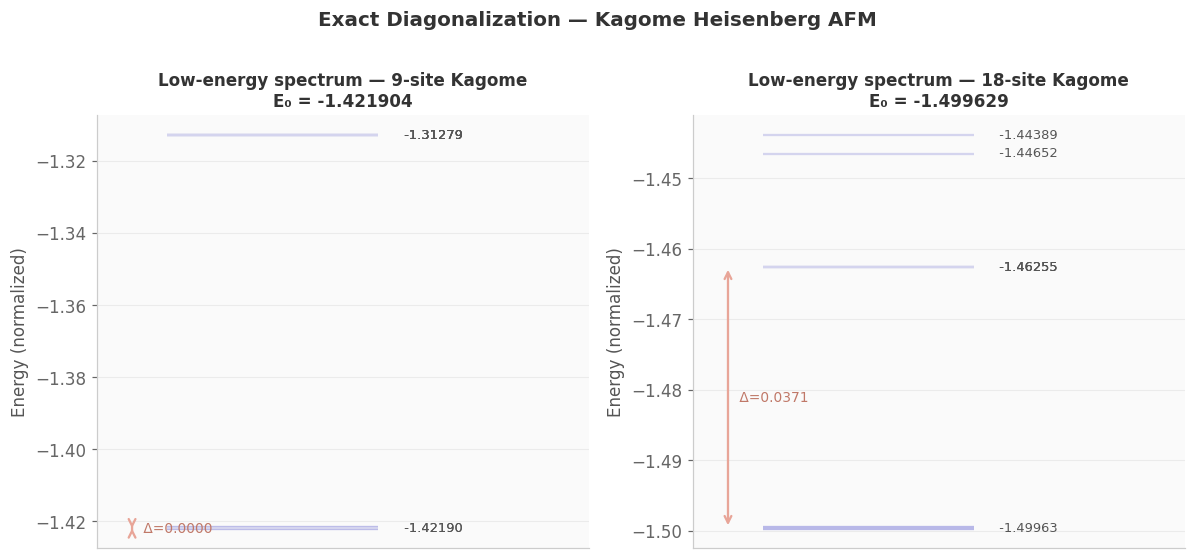

Saved → figures/ed_spectrum.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, evals, n, E0, gap in [
    (axes[0], evals9,  9,  E0_9,  gap9),
    (axes[1], evals18, 18, E0_18, gap18),
]:
    for idx, e in enumerate(evals):
        color = PAL['lavender'] if idx == 0 else '#D4D4EE'
        lw    = 2.8 if idx == 0 else 1.5
        ax.hlines(e, 0.2, 0.8, colors=color, linewidths=lw)
        ax.text(0.85, e, f'  {e:.5f}', va='center',
                fontsize=8.5, color='#555555')

    ax.annotate(
        '', xy=(0.1, evals[1]), xytext=(0.1, evals[0]),
        arrowprops=dict(arrowstyle='<->', color=PAL['coral'], lw=1.5),
    )
    mid_e = (evals[0] + evals[1]) / 2
    ax.text(0.12, mid_e, f' Δ={gap:.4f}',
            va='center', fontsize=9, color='#C07868')

    ax.set_xlim(0, 1.4)
    ax.set_xticks([])
    ax.set_ylabel('Energy (normalized)', color='#555555')
    ax.set_title(
        f'Low-energy spectrum — {n}-site Kagome\nE₀ = {E0:.6f}',
        fontsize=11, fontweight='semibold', color='#333333',
    )

plt.suptitle(
    'Exact Diagonalization — Kagome Heisenberg AFM',
    fontsize=13, fontweight='semibold', color='#333333', y=1.01,
)
plt.tight_layout()
plt.savefig('../figures/ed_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/ed_spectrum.png')

---
## 5. Summary & Reference Energies

In [10]:
rows = [
    (9,  2**9,  len(H9.coeffs),  E0_9,  gap9),
    (18, 2**18, len(H18.coeffs), E0_18, gap18),
]

header = f"{'N':>6}  {'dim':>8}  {'H terms':>8}  {'E₀ (norm.)':>14}  {'Gap Δ':>12}"
print('=== ED Reference Energies ===')
print(header)
print('─' * len(header))
for n, dim, terms, e0, gap in rows:
    print(f'{n:>6}  {dim:>8,}  {terms:>8}  {e0:>14.8f}  {gap:>12.8f}')

# Save CSV for Notebook 02
import csv
with open('../data/ed_reference_energies.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['n_sites', 'hilbert_dim', 'h_terms', 'E0_normalized', 'gap'])
    for row in rows:
        w.writerow(row)
print('\nSaved → data/ed_reference_energies.csv')

=== ED Reference Energies ===
     N       dim   H terms      E₀ (norm.)         Gap Δ
────────────────────────────────────────────────────────
     9       512        42     -1.42190399    0.00000000
    18   262,144        87     -1.49962859    0.03708321

Saved → data/ed_reference_energies.csv


---
## 6. Key Observations

| Quantity | Trend |
|----------|-------|
| Ground state $E_0$ | Decreases (more bonds, lower energy per site) |
| Spectral gap $\Delta$ | Shrinks with $N$ → signature of gapless spin liquid |
| Hamiltonian terms | Scales as $O(N_{\text{bonds}})$ |

The **shrinking spectral gap** with $N$ is a hallmark of the Kagome quantum spin liquid —
the ground state becomes highly degenerate in the thermodynamic limit, making it
exceptionally challenging for variational methods.

> ⚡ **VQE target (Notebook 02)**: the VQE will attempt to reach $E_0$ within 1% using
> both HEA and MERA ansatze. The values above are the reference benchmarks.

---
*spinq-vqe / ARPA QONDRA — Notebook 01*